In [7]:
from pandas import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import json

In [8]:
# Define both datasets
datasets = [
    {
        'id': 0,
        'name': 'CW09',
        'pef_file': "rgb_out/cw09.out",
        # 'pef_file': "new_cw09_2.txt",
        'pisa_file': "/home/angelosav/experiments/pisa/cw09.out",
        'ds2i_file': "/home/angelosav/experiments/vbmw/cw09.out"
    },
    {
        'id': 1,
        'name': 'CCNews',
        'pef_file': "rgb_out/ccnews.out",
        # 'pef_file': "rgb_out/cc_new.out",
        'pisa_file': "/home/angelosav/experiments/pisa/ccnews.out",
        'ds2i_file': "/home/angelosav/experiments/vbmw/ccnews.out"
    }
]

## Process Both Datasets

In [9]:
def format_exp(x):
    """Distinguish between variable and static for BMWand and BMMaxScore"""
    if x['exp'] == "BMWand" or x['exp'] == "BMMaxScore":
        return x['exp'] + " - " + ("var" if 'var' in x['mdata_filename'] else "static")
    return x['exp']

def process_pef_data(pef_file):
    """Read and process PEF results from file"""
    pef_df = []
    for l in open(pef_file, "r").readlines():
        a = l.strip()
        if a.startswith("{") and a.endswith("}"):
            pef_df.append(json.loads(a))
    
    pef_df = DataFrame(pef_df)
    pef_df.loc[:, 'exp'] = pef_df[:].apply(format_exp, axis=1)
    return pef_df

def process_pisa_data(pisa_file):
    """Read and process PISA results from file"""
    pisa_df = []
    for l in open(pisa_file, "r").readlines():
        a = l.strip()
        if a.startswith("{") and a.endswith("}"):
            pisa_df.append(json.loads(a))
    
    pisa_df = DataFrame(pisa_df)
    
    # Rename WAND experiments
    mask = pisa_df['query'] == 'block_max_wand'
    pisa_df.loc[mask, 'query'] = [
        'block_max_wand - static' if i % 2 == 0 else 'block_max_wand - var' 
        for i, _ in enumerate(pisa_df[mask].index)
    ]
    
    # Rename MAXSCORE experiments
    mask = pisa_df['query'] == 'block_max_maxscore'
    pisa_df.loc[mask, 'query'] = [
        'block_max_maxscore - static' if i % 2 == 0 else 'block_max_maxscore - var' 
        for i, _ in enumerate(pisa_df[mask].index)
    ]
    
    return pisa_df

def process_ds2i_data(ds2i_file):
    """Read and process DS2I results from file"""
    ds2i_df = []
    for l in open(ds2i_file, "r").readlines():
        a = l.strip()
        if a.startswith("{") and a.endswith("}"):
            ds2i_df.append(json.loads(a))
    
    ds2i_df = DataFrame(ds2i_df)
    
    # Rename WAND experiments
    mask = ds2i_df['query'] == 'block_max_wand'
    ds2i_df.loc[mask, 'query'] = [
        'block_max_wand - static' if i % 2 == 0 else 'block_max_wand - var' 
        for i, _ in enumerate(ds2i_df[mask].index)
    ]
    
    return ds2i_df

# Process all datasets
dataset_results = {}

for dataset in datasets:
    dataset_name = dataset['name']
    print(f"Processing {dataset_name}...")
    
    # Process PEF data
    pef_df = process_pef_data(dataset['pef_file'])
    
    # Process PISA data
    pisa_df = process_pisa_data(dataset['pisa_file'])
    
    # Process DS2I data
    ds2i_df = process_ds2i_data(dataset['ds2i_file'])
    
    dataset_results[dataset_name] = {
        'pef_df': pef_df,
        'pisa_df': pisa_df,
        'ds2i_df': ds2i_df
    }

print("All datasets processed!")

Processing CW09...
Processing CCNews...
All datasets processed!


## Space Usage Comparison


CW09 Space Usage:
             index_ty  space_usage_MiB vs_opt_str
                EFIdx        18.608398     +35.4%
              UPISIdx        14.962217      +8.9%
             OptEFIdx        13.738740        ref
BlockInterpolativeIdx        13.637246      -0.7%
           OptCompIdx        13.467139      -2.0%
        BlockVByteIdx        46.039463    +235.1%

CCNews Space Usage:
             index_ty  space_usage_MiB vs_opt_str
                EFIdx        20.101406     +67.2%
              UPISIdx        13.502227     +12.3%
             OptEFIdx        12.023164        ref
BlockInterpolativeIdx        12.352764      +2.7%
           OptCompIdx        11.600449      -3.5%
        BlockVByteIdx        54.823652    +356.0%


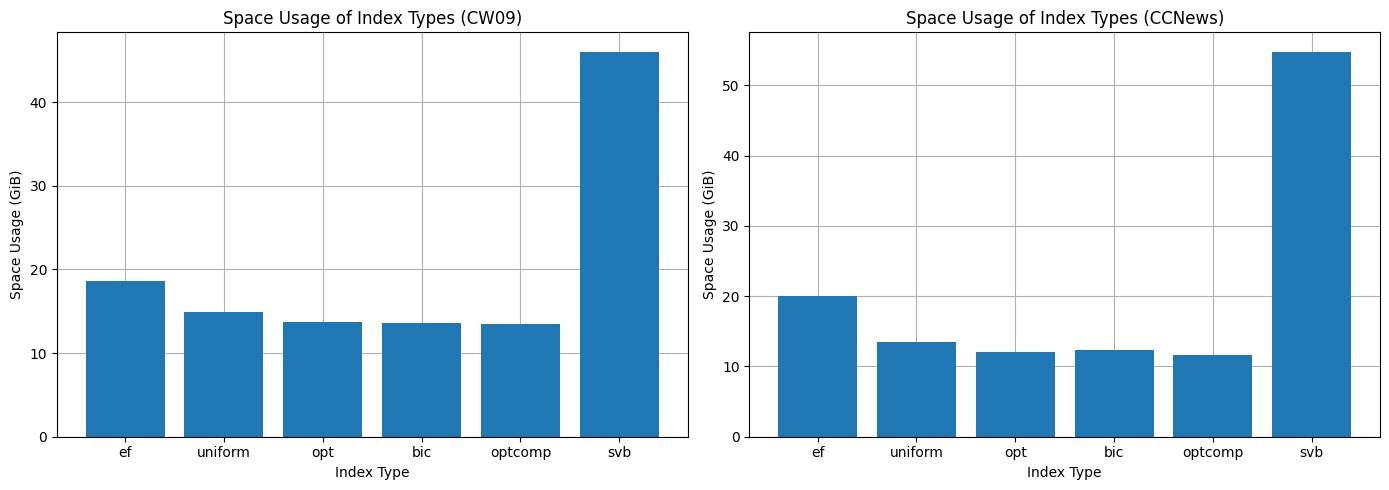

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

preferred_order = ['EFIdx', 'UPISIdx', 'OptEFIdx', 'BlockInterpolativeIdx', 'OptCompIdx', 'BlockVByteIdx']
display_labels = {
    'EFIdx': 'ef',
    'UPISIdx': 'uniform',
    'OptEFIdx': 'opt',
    'BlockInterpolativeIdx': 'bic',
    'BlockVByteIdx': 'svb',
    'OptCompIdx': 'optcomp'
}

for idx, dataset in enumerate(datasets):
    dataset_name = dataset['name']
    pef_df = dataset_results[dataset_name]['pef_df']
    
    pef_df_space = pef_df[['index_ty', 'space_usage_MiB']].drop_duplicates()
    pef_df_space['space_usage_MiB'] = pef_df_space['space_usage_MiB'] / 1024
    
    # Sort by preferred order, include only types present in the data
    present = set(pef_df_space['index_ty'])
    ordered_types = [t for t in preferred_order if t in present]
    pef_df_space = pef_df_space.set_index('index_ty').loc[ordered_types].reset_index()
    
    # Add relative difference vs opt space (e.g. +12.3% or -5.1%)
    opt_rows = pef_df_space[pef_df_space['index_ty'] == 'OptEFIdx']['space_usage_MiB']
    if not opt_rows.empty:
        opt_space = opt_rows.iloc[0]
        pef_df_space['vs_opt'] = ((pef_df_space['space_usage_MiB'] - opt_space) / opt_space * 100).round(1)
        pef_df_space['vs_opt_str'] = pef_df_space['vs_opt'].apply(lambda x: f"+{x}%" if x > 0 else (f"{x}%" if x < 0 else "ref"))
    
    ax = axes[idx]
    ax.bar([display_labels[t] for t in pef_df_space['index_ty']], pef_df_space['space_usage_MiB'], zorder=2)
    ax.grid(zorder=3)
    ax.set_title(f'Space Usage of Index Types ({dataset_name})')
    ax.set_xlabel('Index Type')
    ax.set_ylabel('Space Usage (GiB)')
    
    print(f"\n{dataset_name} Space Usage:")
    cols = ['index_ty', 'space_usage_MiB'] + (['vs_opt_str'] if 'vs_opt_str' in pef_df_space.columns else [])
    print(pef_df_space[cols].to_string(index=False))

plt.tight_layout()
plt.show()


In [11]:
def create_pef_times_df(pef_df):
    """Create formatted time comparison dataframe for PEF"""
    # Reshape the dataframe
    pef_df_times = pef_df.pivot(index='index_ty', columns='exp', values='avg')
    pef_df_times.columns.name = None
    
    ordered_index = ['EFIdx', 'UPISIdx', 'OptEFIdx', 'BlockInterpolativeIdx', 'BlockVByteIdx', 'OptCompIdx']
    ordered_columns = ['And', 'RankedAnd', 'RankedOr', 'Wand', 'MaxScore', 'BMWand - static','BMMaxScore - static', 'BMWand - var','BMMaxScore - var']
    
    # Only reindex with rows/columns that are present
    ordered_index = [i for i in ordered_index if i in pef_df_times.index]
    ordered_columns = [c for c in ordered_columns if c in pef_df_times.columns]
    
    pef_df_times = pef_df_times.reindex(ordered_index)
    pef_df_times = pef_df_times[ordered_columns]
    pef_df_times = pef_df_times / 1000
    
    pef_df_times = pef_df_times.rename(columns={
        'And': 'and',
        'RankedAnd': 'ranked_and',
        'RankedOr': 'ranked_or',
        'Wand': 'wand',
        'MaxScore': 'maxscore',
        'BMWand - static': 'block_max_wand - static',
        'BMMaxScore - static': 'block_max_maxscore - static',
        'BMWand - var': 'block_max_wand - var',
        'BMMaxScore - var': 'block_max_maxscore - var'
    })
    
    pef_df_times = pef_df_times.rename(index={
        'EFIdx': 'ef',
        'UPISIdx': 'uniform',
        'OptEFIdx': 'opt',
        'BlockInterpolativeIdx': 'block_interpolative',
        'BlockVByteIdx': 'block_svb/varint',
        'OptCompIdx': 'optcomp'
    })
    
    pef_df_times = pef_df_times.rename_axis('type')
    return pef_df_times

def create_pisa_times_df(pisa_df):
    """Create formatted time comparison dataframe for PISA"""
    pisa_df_times = pisa_df.pivot(index='type', columns='query', values='avg')
    pisa_df_times.columns.name = None
    
    pisa_df_times = pisa_df_times.rename(index={
        'pefopt': 'opt',
        'pefuniform': 'uniform',
        'block_streamvbyte': 'block_svb/varint',
    })
    
    pisa_df_times = pisa_df_times / 1000
    return pisa_df_times

def create_ds2i_times_df(ds2i_df):
    """Create formatted time comparison dataframe for DS2I"""
    ds2i_df_times = ds2i_df.pivot(index='type', columns='query', values='avg')
    ds2i_df_times.columns.name = None
    
    ds2i_df_times = ds2i_df_times.rename(index={
        'block_varint': 'block_svb/varint'
    })
    
    ds2i_df_times = ds2i_df_times / 1000
    return ds2i_df_times

# Create time dataframes for all datasets
for dataset in datasets:
    dataset_name = dataset['name']
    print(f"\n{'='*50}")
    print(f"Processing times for {dataset_name}")
    print(f"{'='*50}")
    
    pef_df_times = create_pef_times_df(dataset_results[dataset_name]['pef_df'])
    pisa_df_times = create_pisa_times_df(dataset_results[dataset_name]['pisa_df'])
    ds2i_df_times = create_ds2i_times_df(dataset_results[dataset_name]['ds2i_df'])
    
    dataset_results[dataset_name]['pef_df_times'] = pef_df_times
    dataset_results[dataset_name]['pisa_df_times'] = pisa_df_times
    dataset_results[dataset_name]['ds2i_df_times'] = ds2i_df_times
    
    print(f"\n{dataset_name} PEF Times:")
    print(pef_df_times)



Processing times for CW09

CW09 PEF Times:
                        and  ranked_and  ranked_or    wand  maxscore  \
type                                                                   
ef                    5.735       9.416    107.430  12.082    10.114   
uniform               7.211      11.864    132.626  15.463    11.131   
opt                   6.246      10.393    127.054  13.421    11.192   
block_interpolative  19.648      35.386    231.058  43.415    18.692   
block_svb/varint      4.864       6.818     72.911   9.990     7.135   
optcomp               6.966      11.167    131.591  14.421    11.695   

                     block_max_wand - static  block_max_maxscore - static  \
type                                                                        
ef                                     4.392                       10.714   
uniform                                4.947                       11.894   
opt                                    4.406                       12.0

# Combined Results - Query Times

In [12]:
def combine_all_results(pef_df_times, pisa_df_times, ds2i_df_times):
    """Combine PEF, PISA, and DS2I results into a single dataframe"""
    pef_df_times['lib'] = 'PEF'
    ds2i_df_times['lib'] = 'DS2I'
    pisa_df_times['lib'] = 'PISA'
    
    df = pd.concat([pef_df_times, ds2i_df_times, pisa_df_times], axis=0).reset_index().set_index(['type', 'lib']).sort_index()
    
    # Reorder index
    type_order = ['ef', 'uniform', 'opt', 'optcomp', 'block_interpolative', 'block_svb/varint']
    lib_order = ['PEF', 'PISA', 'DS2I']
    
    # Only reindex with types that are present
    present_types = df.index.get_level_values('type').unique().tolist()
    type_order = [t for t in type_order if t in present_types]
    
    df = df.reindex(type_order, level='type')
    df = df.reindex(lib_order, level='lib')
    
    df = df.round(1)
    return df

# Create combined dataframes for both datasets
combined_results = {}

for dataset in datasets:
    dataset_name = dataset['name']
    df = combine_all_results(
        dataset_results[dataset_name]['pef_df_times'].copy(),
        dataset_results[dataset_name]['pisa_df_times'].copy(),
        dataset_results[dataset_name]['ds2i_df_times'].copy()
    )
    combined_results[dataset_name] = df
    
    print(f"\n{'='*80}")
    print(f"Combined Results for {dataset_name}")
    print(f"{'='*80}")
    print(df)



Combined Results for CW09
                           and  ranked_and  ranked_or  wand  maxscore  \
type                lib                                                 
ef                  PEF    5.7         9.4      107.4  12.1      10.1   
                    PISA   6.0         9.2      157.9  12.3       9.3   
                    DS2I   5.9         NaN      117.2  12.9      10.0   
uniform             PEF    7.2        11.9      132.6  15.5      11.1   
                    PISA   6.8        10.3      165.0  13.4      10.4   
                    DS2I   5.6         NaN      120.6  13.0       9.3   
opt                 PEF    6.2        10.4      127.1  13.4      11.2   
                    PISA   6.1         9.6      160.4  12.8      10.4   
                    DS2I   5.3         NaN      114.8  12.3       8.9   
optcomp             PEF    7.0        11.2      131.6  14.4      11.7   
block_interpolative PEF   19.6        35.4      231.1  43.4      18.7   
                    PISA

## Times - AND / Ranked AND / Ranked OR (Both Datasets)

In [13]:
for dataset in datasets:
    dataset_name = dataset['name']
    df = combined_results[dataset_name]
    mask = df.index.get_level_values('lib').isin(['PEF', 'DS2I', 'PISA'])
    
    print(f"\n{'='*80}")
    print(f"{dataset_name} - AND / Ranked AND / Ranked OR")
    print(f"{'='*80}")
    print(df[mask][['ranked_or', 'and', 'ranked_and']])


CW09 - AND / Ranked AND / Ranked OR
                          ranked_or   and  ranked_and
type                lib                              
ef                  PEF       107.4   5.7         9.4
                    PISA      157.9   6.0         9.2
                    DS2I      117.2   5.9         NaN
uniform             PEF       132.6   7.2        11.9
                    PISA      165.0   6.8        10.3
                    DS2I      120.6   5.6         NaN
opt                 PEF       127.1   6.2        10.4
                    PISA      160.4   6.1         9.6
                    DS2I      114.8   5.3         NaN
optcomp             PEF       131.6   7.0        11.2
block_interpolative PEF       231.1  19.6        35.4
                    PISA      312.8  23.4        42.3
                    DS2I      236.6  20.2         NaN
block_svb/varint    PEF        72.9   4.9         6.8
                    PISA      110.9   4.9         6.6
                    DS2I       64.2   4.5    

In [14]:
for dataset in datasets:
    dataset_name = dataset['name']
    df = combined_results[dataset_name]
    mask = df.index.get_level_values('lib').isin(['PEF', 'DS2I', 'PISA'])
    
    print(f"\n{'='*80}")
    print(f"{dataset_name} - LaTeX Table")
    print(f"{'='*80}")
    print(df[mask][['ranked_or', 'and', 'ranked_and']].to_latex(escape=True, float_format="%.1f"))


CW09 - LaTeX Table
\begin{tabular}{llrrr}
\toprule
 &  & ranked\_or & and & ranked\_and \\
type & lib &  &  &  \\
\midrule
\multirow[t]{3}{*}{ef} & PEF & 107.4 & 5.7 & 9.4 \\
 & PISA & 157.9 & 6.0 & 9.2 \\
 & DS2I & 117.2 & 5.9 & NaN \\
\cline{1-5}
\multirow[t]{3}{*}{uniform} & PEF & 132.6 & 7.2 & 11.9 \\
 & PISA & 165.0 & 6.8 & 10.3 \\
 & DS2I & 120.6 & 5.6 & NaN \\
\cline{1-5}
\multirow[t]{3}{*}{opt} & PEF & 127.1 & 6.2 & 10.4 \\
 & PISA & 160.4 & 6.1 & 9.6 \\
 & DS2I & 114.8 & 5.3 & NaN \\
\cline{1-5}
optcomp & PEF & 131.6 & 7.0 & 11.2 \\
\cline{1-5}
\multirow[t]{3}{*}{block\_interpolative} & PEF & 231.1 & 19.6 & 35.4 \\
 & PISA & 312.8 & 23.4 & 42.3 \\
 & DS2I & 236.6 & 20.2 & NaN \\
\cline{1-5}
\multirow[t]{3}{*}{block\_svb/varint} & PEF & 72.9 & 4.9 & 6.8 \\
 & PISA & 110.9 & 4.9 & 6.6 \\
 & DS2I & 64.2 & 4.5 & NaN \\
\cline{1-5}
\bottomrule
\end{tabular}


CCNews - LaTeX Table
\begin{tabular}{llrrr}
\toprule
 &  & ranked\_or & and & ranked\_and \\
type & lib &  &  &  \\
\midrul

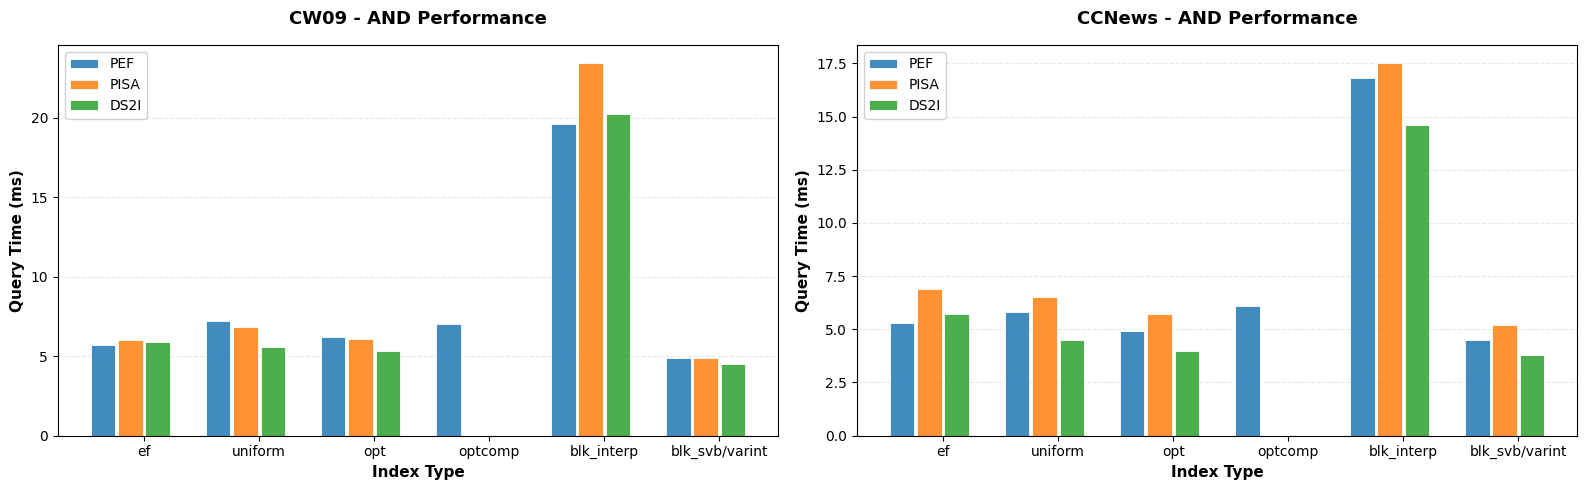

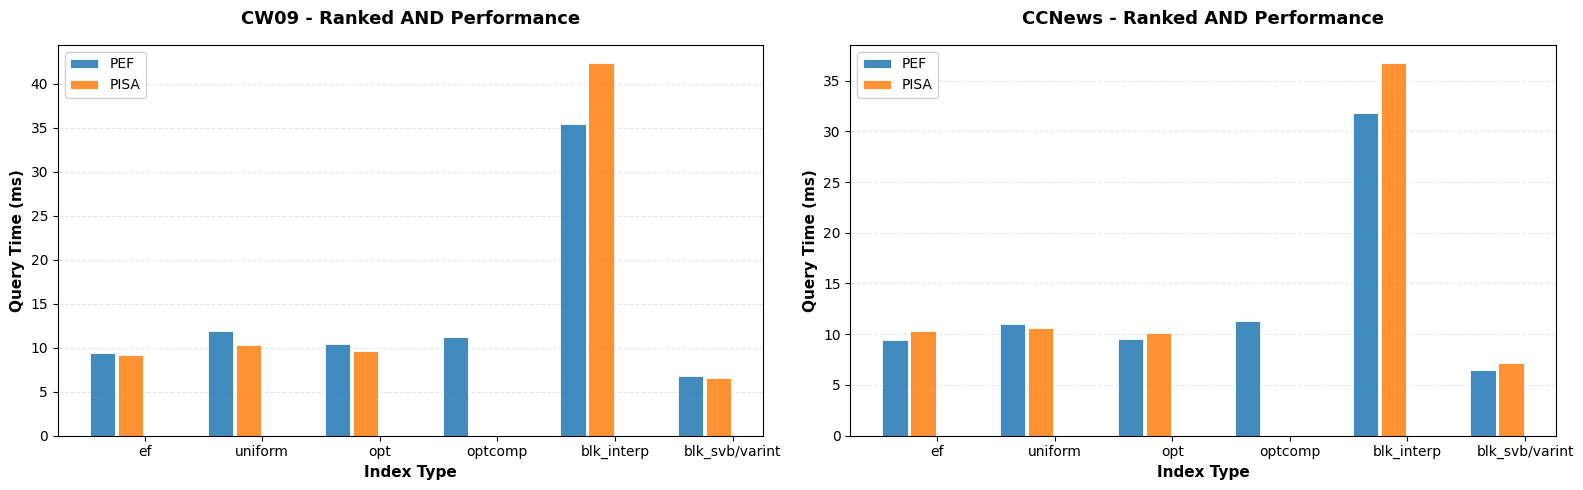

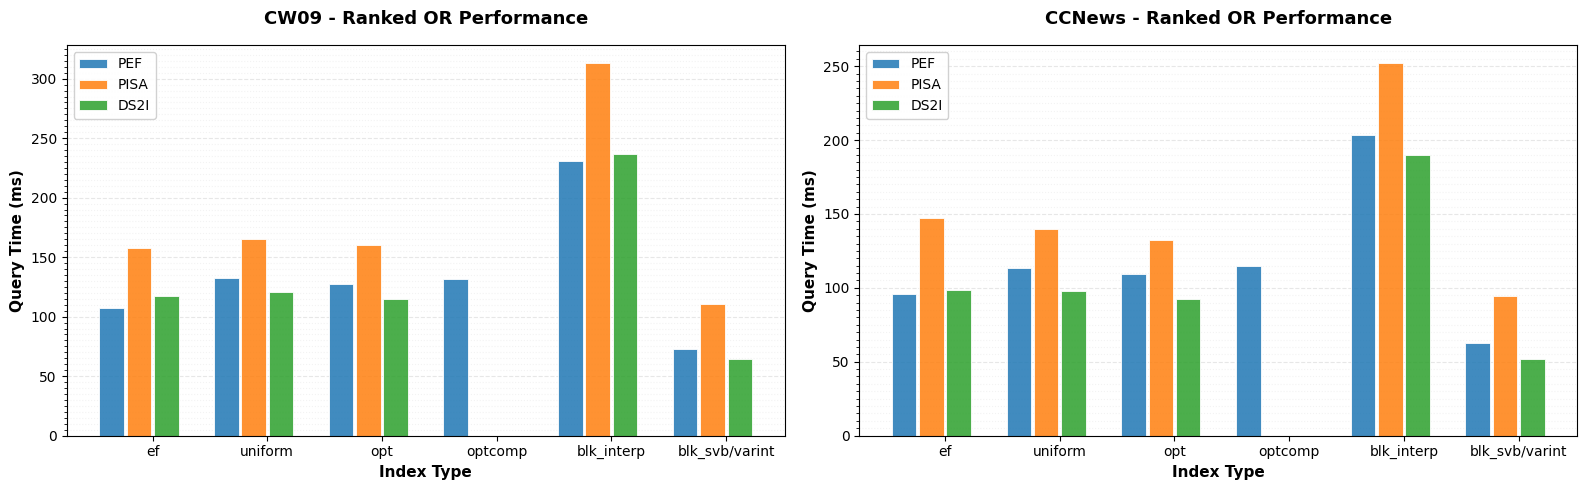

In [15]:
# Visualize AND / Ranked AND / Ranked OR times - separate plots for each query type
import numpy as np

query_types = ['and', 'ranked_and', 'ranked_or']
query_labels = {'and': 'AND', 'ranked_and': 'Ranked AND', 'ranked_or': 'Ranked OR'}
lib_colors = {'PEF': '#1f77b4', 'PISA': '#ff7f0e', 'DS2I': '#2ca02c'}
libs = ['PEF', 'PISA', 'DS2I']

# Create a separate figure for each query type
for query_type in query_types:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    for dataset_idx, dataset in enumerate(datasets):
        dataset_name = dataset['name']
        df = combined_results[dataset_name]
        mask = df.index.get_level_values('lib').isin(['PEF', 'DS2I', 'PISA'])
        data = df[mask][query_type]
        
        ax = axes[dataset_idx]
        
        # Get unique index types
        index_types = data.index.get_level_values('type').unique().tolist()
        
        # Calculate positions for grouped bars
        n_index_types = len(index_types)
        n_libs = len(libs)
        
        bar_width = 0.25
        group_width = n_libs * bar_width
        group_gap = 0.3
        
        # Plot bars grouped by index type
        for type_idx, idx_type in enumerate(index_types):
            base_pos = type_idx * (group_width + group_gap)
            
            for lib_idx, lib in enumerate(libs):
                if (idx_type, lib) in data.index:
                    val = data.loc[(idx_type, lib)]
                    if pd.notna(val):
                        # Position calculation: base + library offset
                        pos = base_pos + lib_idx * bar_width
                        
                        # Only add label for the first index type
                        label = lib if type_idx == 0 else ""
                        
                        ax.bar(pos, val, bar_width * 0.9, 
                               color=lib_colors[lib], 
                               alpha=0.85,
                               edgecolor='white',
                               linewidth=0.7,
                               label=label,
                               zorder=2)
        
        # Customize the plot
        ax.set_xlabel('Index Type', fontsize=11, fontweight='bold')
        ax.set_ylabel('Query Time (ms)', fontsize=11, fontweight='bold')
        ax.set_title(f'{dataset_name} - {query_labels[query_type]} Performance', 
                     fontsize=13, fontweight='bold', pad=15)
        
        # Set x-axis ticks at the center of each group
        group_centers = [i * (group_width + group_gap) + group_width / 2 for i in range(n_index_types)]
        ax.set_xticks(group_centers)
        
        # Shorten index type names for readability
        short_labels = [t.replace('block_', 'blk_').replace('interpolative', 'interp') 
                        for t in index_types]
        ax.set_xticklabels(short_labels, fontsize=10)
        
        ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
        ax.grid(axis='y', zorder=1, alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        
        # Add minor gridlines for better readability
        ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
        ax.grid(which='minor', axis='y', alpha=0.15, linestyle=':')
    
    plt.tight_layout()
    plt.show()

## Times - Wand / MaxScore (Both Datasets)

In [16]:
for dataset in datasets:
    dataset_name = dataset['name']
    df = combined_results[dataset_name]
    mask = df.index.get_level_values('lib').isin(['PEF', 'PISA', 'DS2I'])
    
    print(f"\n{'='*80}")
    print(f"{dataset_name} - Wand / MaxScore")
    print(f"{'='*80}")
    print(df[mask][['wand', 'maxscore']])


CW09 - Wand / MaxScore
                          wand  maxscore
type                lib                 
ef                  PEF   12.1      10.1
                    PISA  12.3       9.3
                    DS2I  12.9      10.0
uniform             PEF   15.5      11.1
                    PISA  13.4      10.4
                    DS2I  13.0       9.3
opt                 PEF   13.4      11.2
                    PISA  12.8      10.4
                    DS2I  12.3       8.9
optcomp             PEF   14.4      11.7
block_interpolative PEF   43.4      18.7
                    PISA  52.0      19.6
                    DS2I  46.6      17.2
block_svb/varint    PEF   10.0       7.1
                    PISA   9.5       5.9
                    DS2I   9.1       5.2

CCNews - Wand / MaxScore
                          wand  maxscore
type                lib                 
ef                  PEF   13.2      11.2
                    PISA  14.3      11.3
                    DS2I  13.8      10.9
uniform

## Times - Block Versions (Both Datasets)

In [17]:
for dataset in datasets:
    dataset_name = dataset['name']
    df = combined_results[dataset_name]
    mask = df.index.get_level_values('lib').isin(['PEF', 'PISA', 'DS2I'])
    
    print(f"\n{'='*80}")
    print(f"{dataset_name} - Block Max Wand / MaxScore")
    print(f"{'='*80}")
    print(df[mask][['block_max_wand - static', 'block_max_maxscore - static', 'block_max_wand - var', 'block_max_maxscore - var']])


CW09 - Block Max Wand / MaxScore
                          block_max_wand - static  \
type                lib                             
ef                  PEF                       4.4   
                    PISA                      5.4   
                    DS2I                      5.6   
uniform             PEF                       4.9   
                    PISA                      5.6   
                    DS2I                      5.3   
opt                 PEF                       4.4   
                    PISA                      5.5   
                    DS2I                      5.3   
optcomp             PEF                       4.6   
block_interpolative PEF                      16.0   
                    PISA                     19.6   
                    DS2I                     17.4   
block_svb/varint    PEF                       3.8   
                    PISA                      5.0   
                    DS2I                      5.1   

           

# Cross-Dataset Comparison

In [18]:
# Compare PEF performance across datasets
print("PEF Performance Comparison (CW09 vs CCNews)")
print("="*80)

cw09_pef = combined_results['CW09'].loc[combined_results['CW09'].index.get_level_values('lib') == 'PEF']
ccnews_pef = combined_results['CCNews'].loc[combined_results['CCNews'].index.get_level_values('lib') == 'PEF']

# Select common columns for comparison
common_cols = ['and', 'ranked_and', 'ranked_or', 'wand', 'maxscore']
comparison = pd.DataFrame({
    'CW09': cw09_pef[common_cols].mean(),
    'CCNews': ccnews_pef[common_cols].mean()
})
comparison['Ratio (CCNews/CW09)'] = comparison['CCNews'] / comparison['CW09']
print(comparison.round(2))

PEF Performance Comparison (CW09 vs CCNews)
              CW09  CCNews  Ratio (CCNews/CW09)
and           8.43    7.23                 0.86
ranked_and   14.18   13.25                 0.93
ranked_or   133.78  116.48                 0.87
wand         18.13   19.17                 1.06
maxscore     11.65   12.55                 1.08


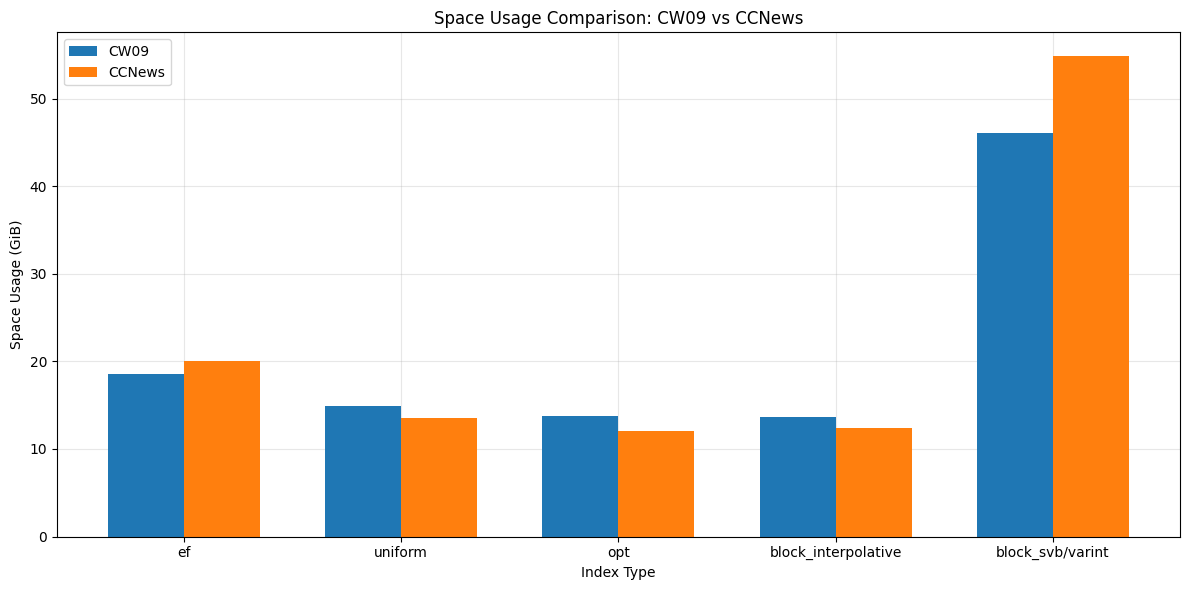

In [19]:
# Visualize space usage comparison across datasets
index_types = ['ef', 'uniform', 'opt', 'block_interpolative', 'block_svb/varint']
x = range(len(index_types))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

cw09_space = []
ccnews_space = []

for idx_type in index_types:
    cw09_pef = dataset_results['CW09']['pef_df']
    ccnews_pef = dataset_results['CCNews']['pef_df']
    
    # Map index type names
    type_map = {
        'ef': 'EFIdx',
        'uniform': 'UPISIdx', 
        'opt': 'OptEFIdx',
        'block_interpolative': 'BlockInterpolativeIdx',
        'block_svb/varint': 'BlockVByteIdx'
    }
    
    cw09_val = cw09_pef[cw09_pef['index_ty'] == type_map[idx_type]]['space_usage_MiB'].iloc[0] / 1024 if len(cw09_pef[cw09_pef['index_ty'] == type_map[idx_type]]) > 0 else 0
    ccnews_val = ccnews_pef[ccnews_pef['index_ty'] == type_map[idx_type]]['space_usage_MiB'].iloc[0] / 1024 if len(ccnews_pef[ccnews_pef['index_ty'] == type_map[idx_type]]) > 0 else 0
    
    cw09_space.append(cw09_val)
    ccnews_space.append(ccnews_val)

ax.bar([i - width/2 for i in x], cw09_space, width, label='CW09', zorder=2)
ax.bar([i + width/2 for i in x], ccnews_space, width, label='CCNews', zorder=2)

ax.set_xlabel('Index Type')
ax.set_ylabel('Space Usage (GiB)')
ax.set_title('Space Usage Comparison: CW09 vs CCNews')
ax.set_xticks(x)
ax.set_xticklabels(index_types)
ax.legend()
ax.grid(zorder=1, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Summary statistics for both datasets
print("\nSummary Statistics")
print("="*80)

for dataset in datasets:
    dataset_name = dataset['name']
    df = combined_results[dataset_name]
    
    print(f"\n{dataset_name}:")
    print(f"  Min query time: {df.min().min():.1f} ms")
    print(f"  Max query time: {df.max().max():.1f} ms")
    print(f"  Avg query time: {df.mean().mean():.1f} ms")


Summary Statistics

CW09:
  Min query time: 3.2 ms
  Max query time: 312.8 ms
  Avg query time: 25.0 ms

CCNews:
  Min query time: 2.9 ms
  Max query time: 251.9 ms
  Avg query time: 22.7 ms


# Complete Query Performance Visualization

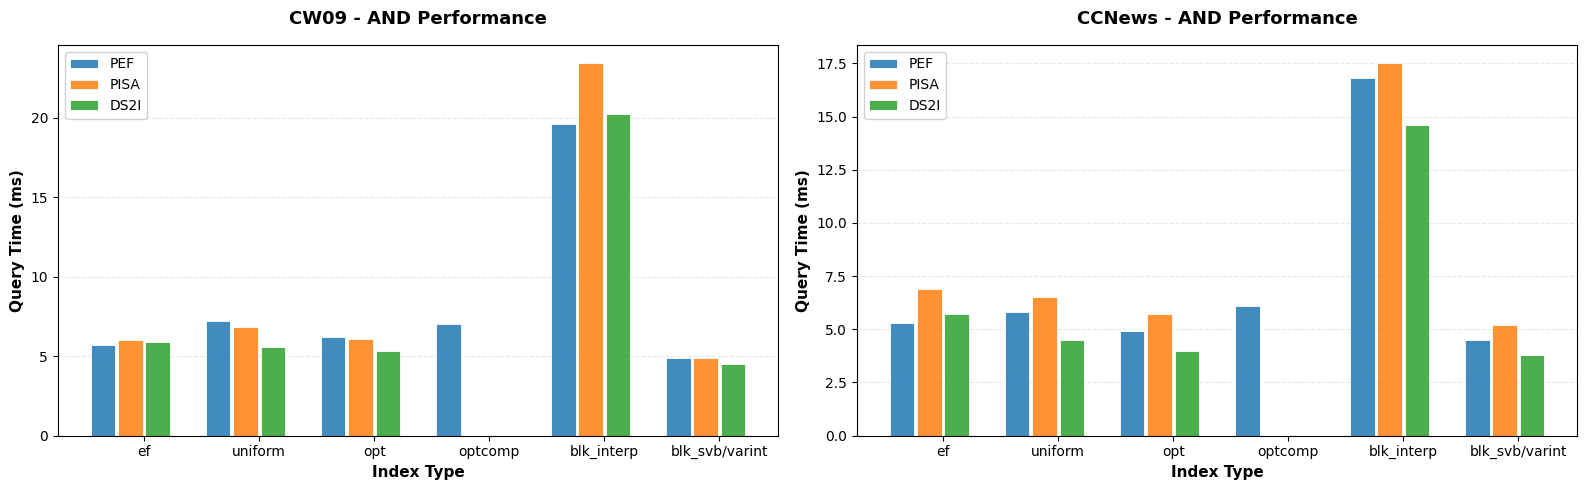

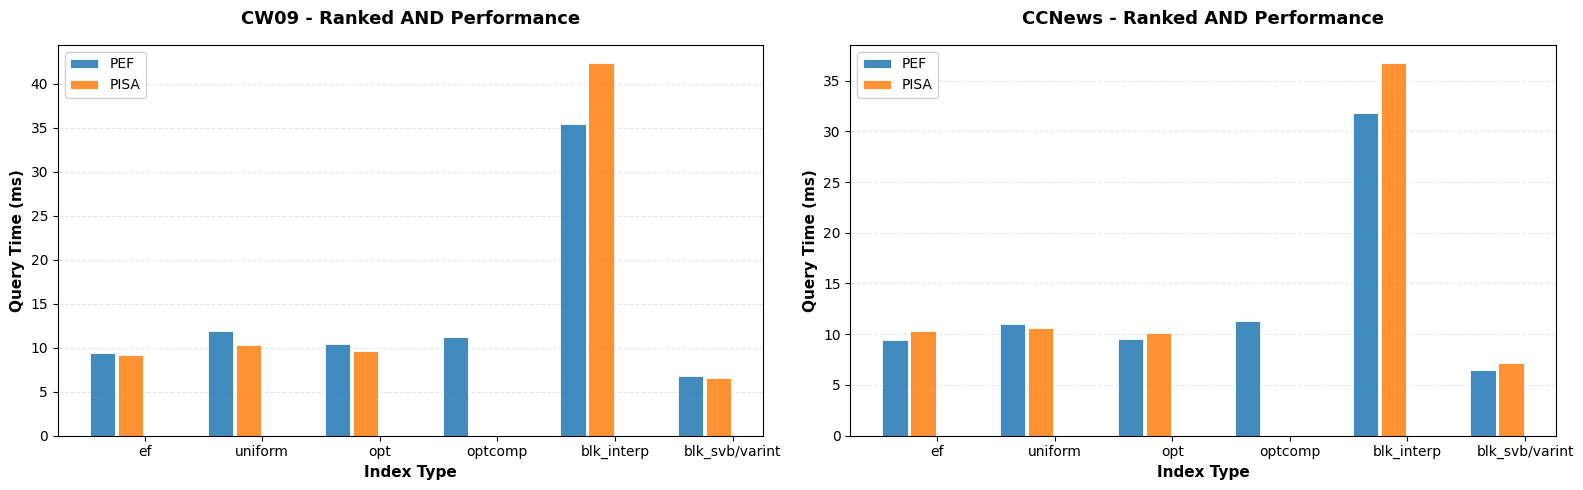

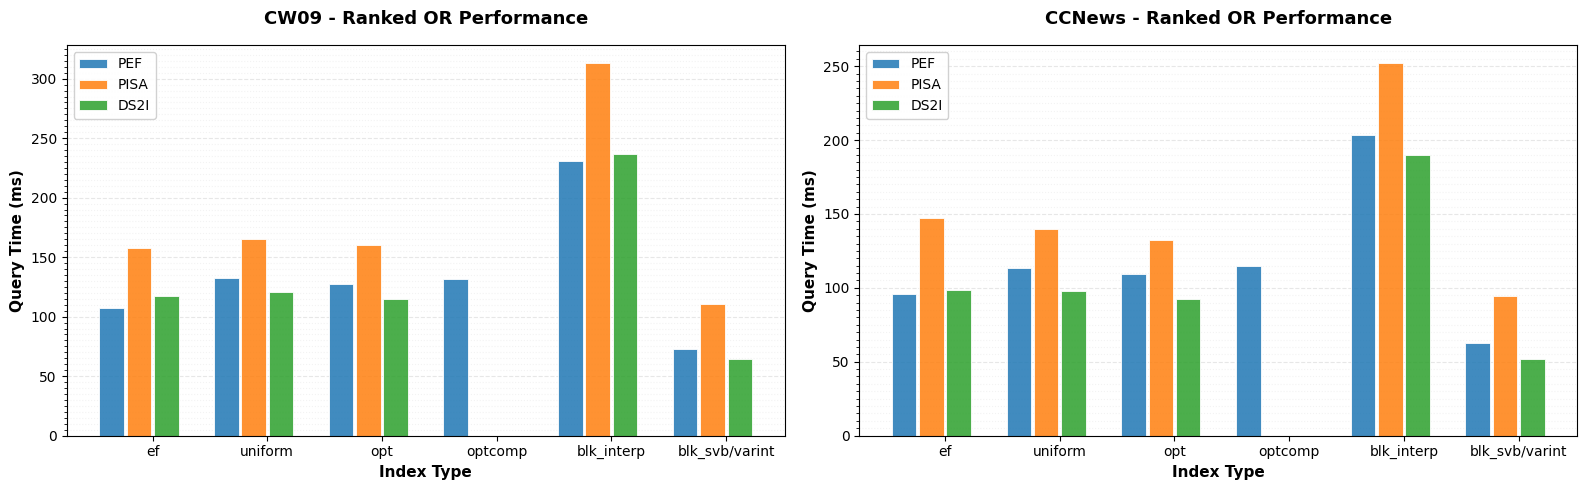

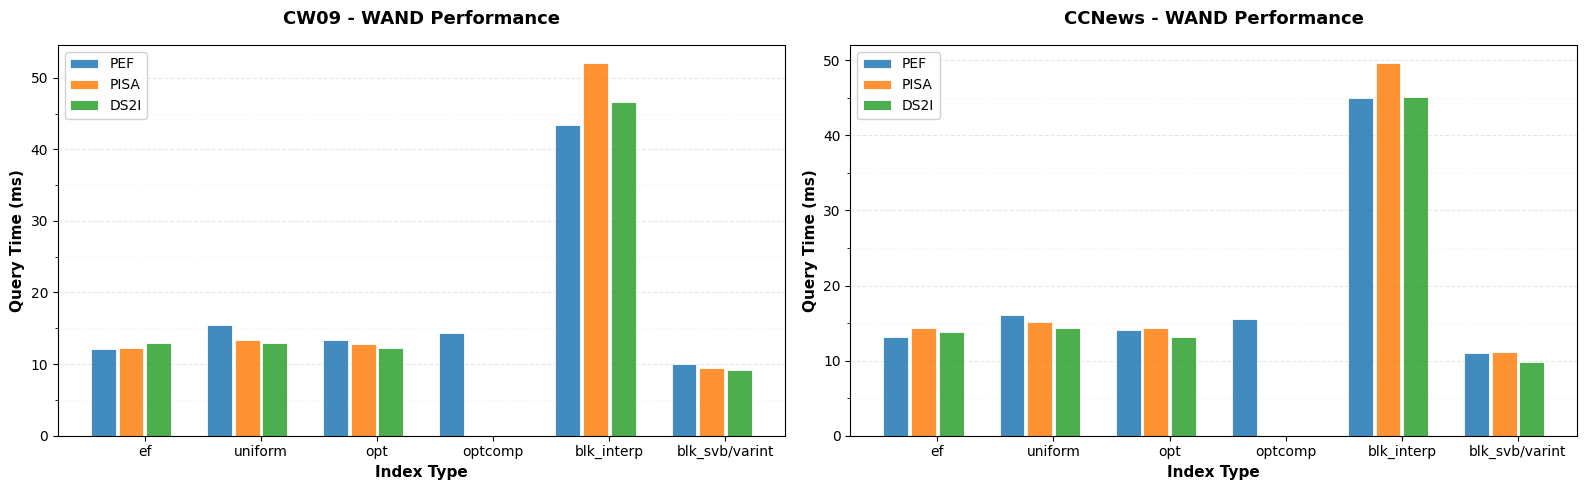

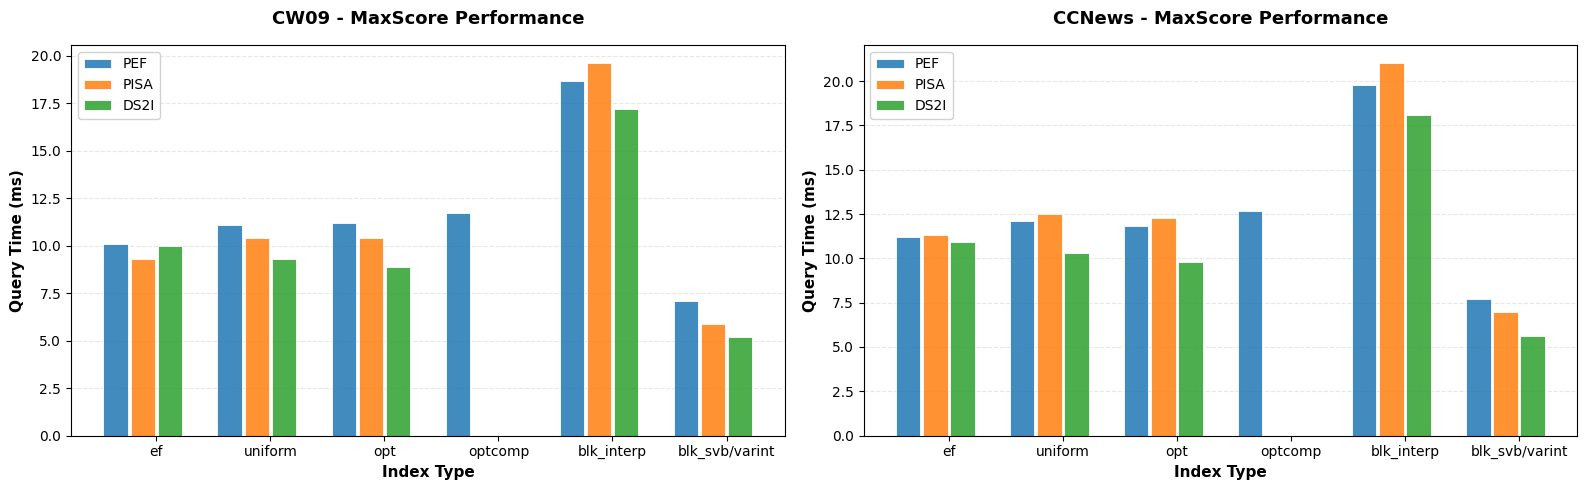

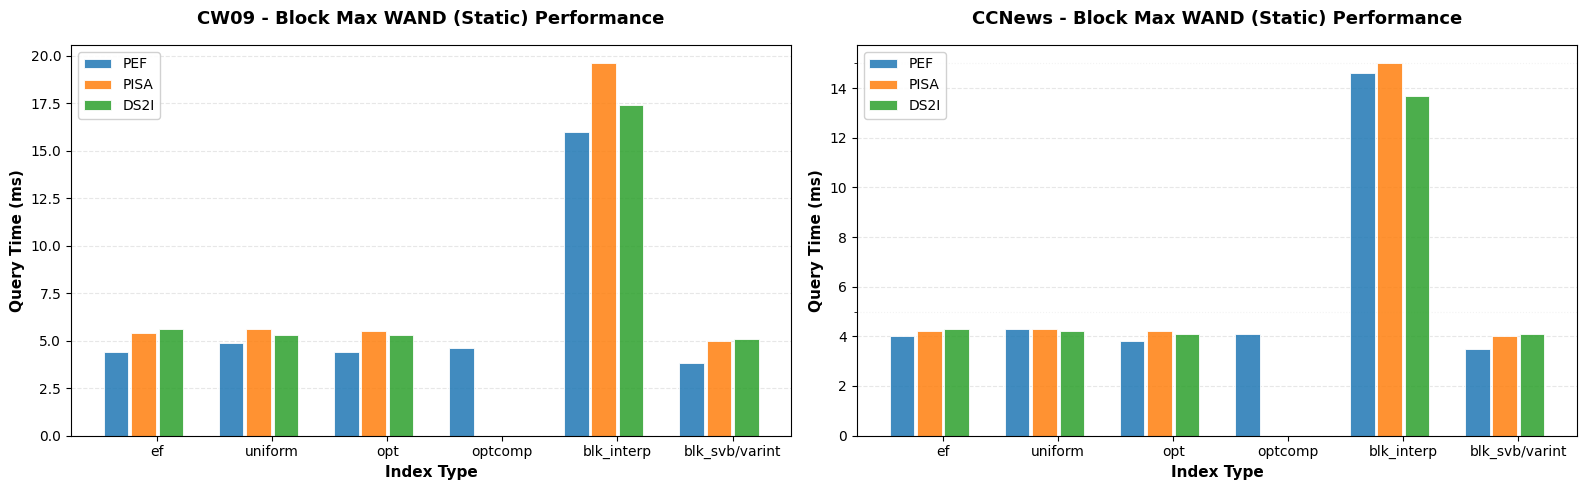

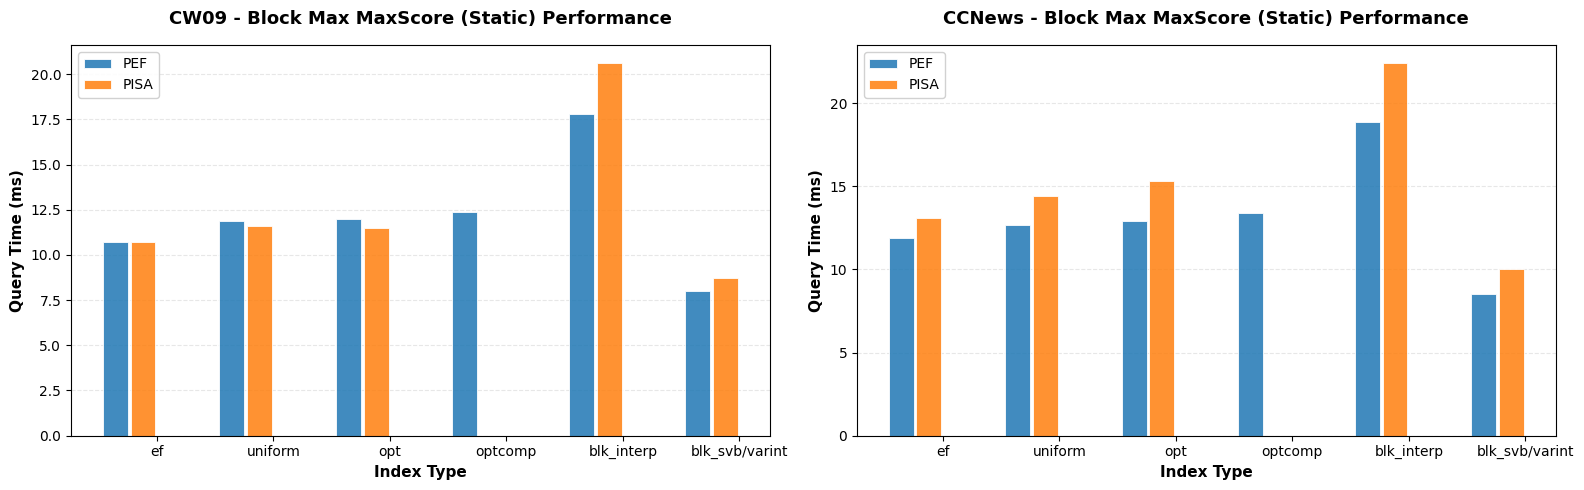

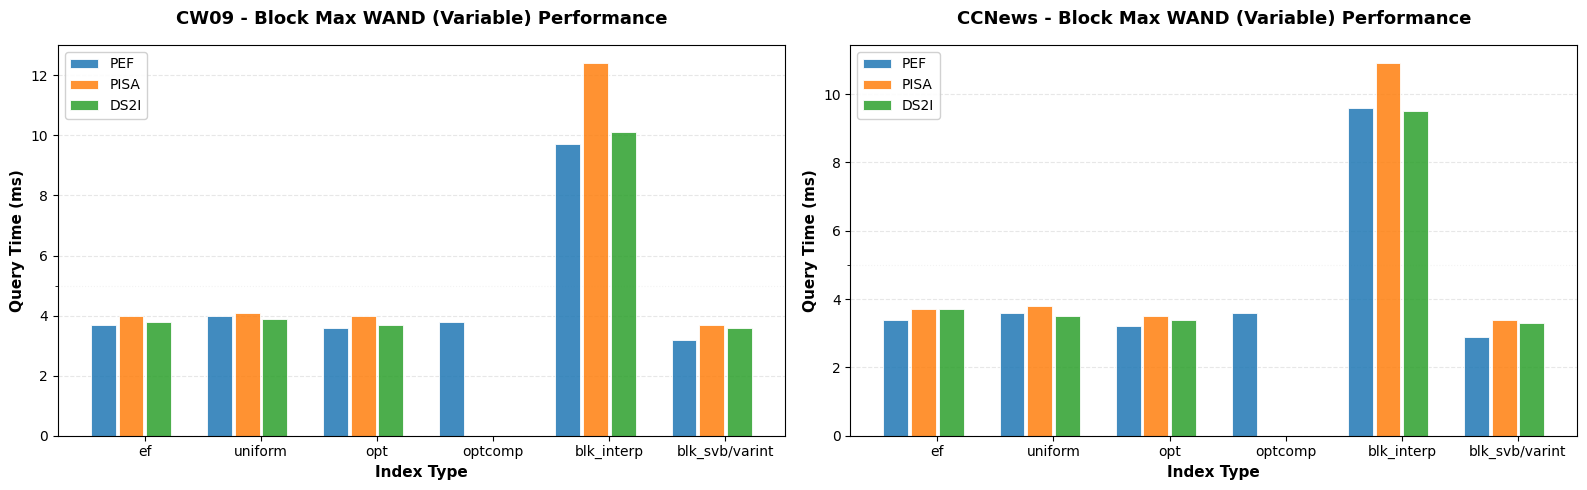

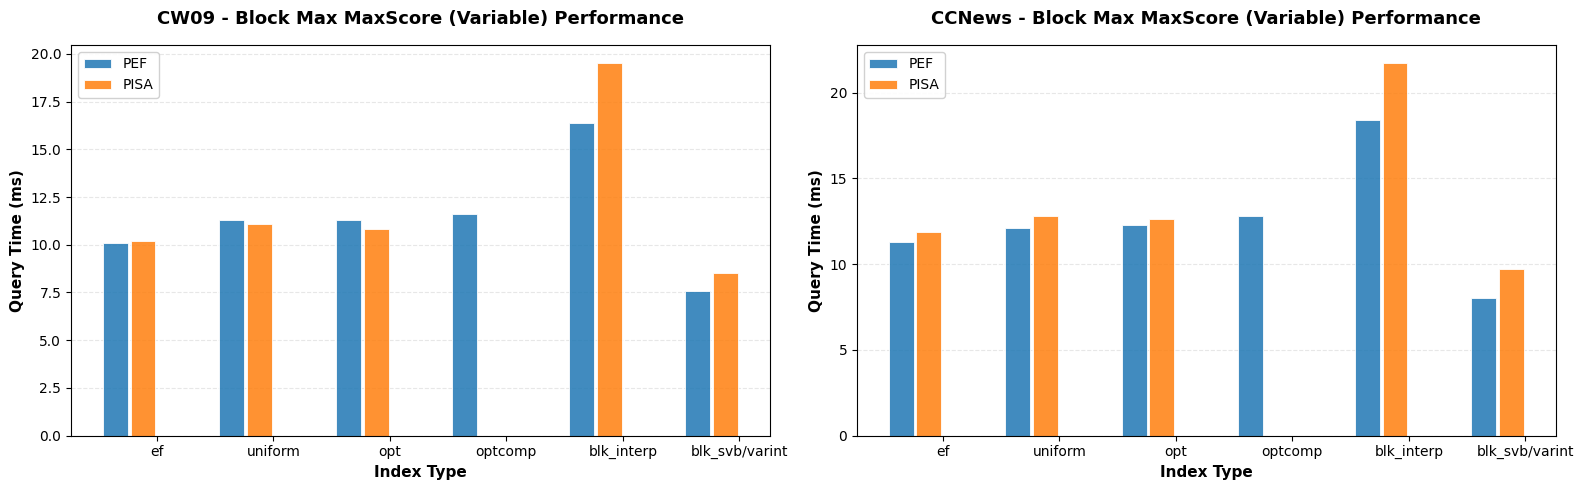

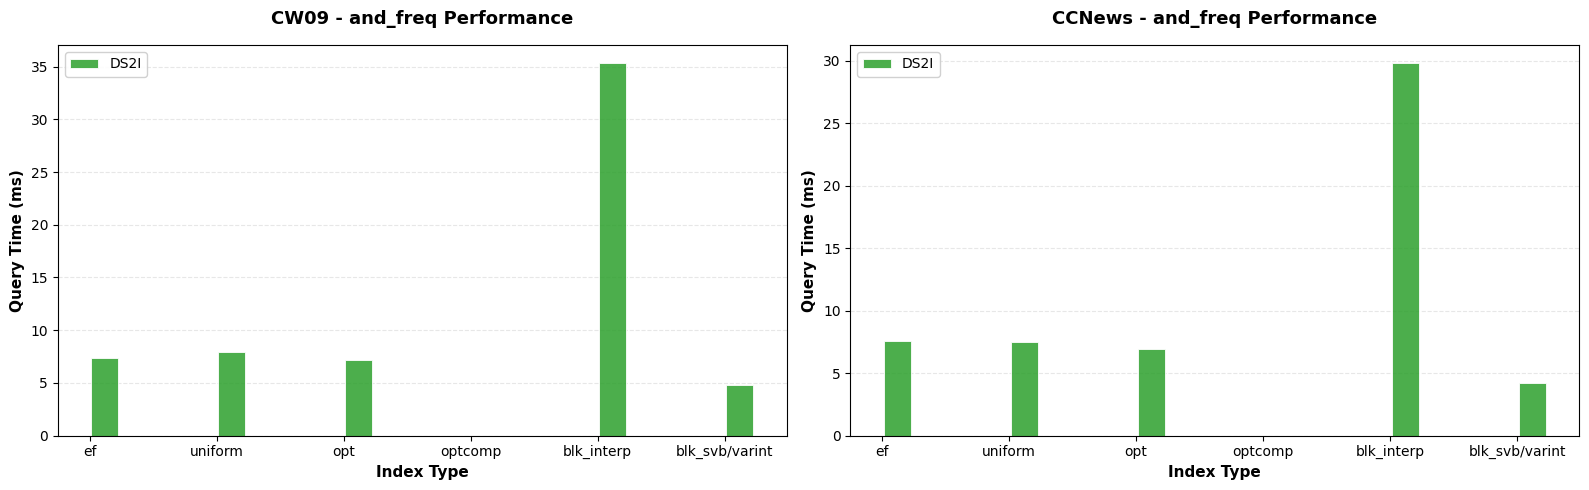

In [21]:
# Visualize all query types - separate plots for each
import numpy as np

# Get all available query columns
sample_df = combined_results['CW09']
all_query_types = [col for col in sample_df.columns if col not in ['lib']]

# Define nice labels for all queries
query_labels_full = {
    'and': 'AND',
    'ranked_and': 'Ranked AND',
    'ranked_or': 'Ranked OR',
    'wand': 'WAND',
    'maxscore': 'MaxScore',
    'block_max_wand - static': 'Block Max WAND (Static)',
    'block_max_maxscore - static': 'Block Max MaxScore (Static)',
    'block_max_wand - var': 'Block Max WAND (Variable)',
    'block_max_maxscore - var': 'Block Max MaxScore (Variable)'
}

lib_colors = {'PEF': '#1f77b4', 'PISA': '#ff7f0e', 'DS2I': '#2ca02c'}
libs = ['PEF', 'PISA', 'DS2I']

# Create a separate figure for each query type
for query_type in all_query_types:
    # Check if this query has data for all datasets
    has_data = all(query_type in combined_results[ds['name']].columns for ds in datasets)
    if not has_data:
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    for dataset_idx, dataset in enumerate(datasets):
        dataset_name = dataset['name']
        df = combined_results[dataset_name]
        mask = df.index.get_level_values('lib').isin(['PEF', 'DS2I', 'PISA'])
        
        # Check if query_type exists in this dataset
        if query_type not in df.columns:
            continue
            
        data = df[mask][query_type]
        
        ax = axes[dataset_idx]
        
        # Get unique index types
        index_types = data.index.get_level_values('type').unique().tolist()
        
        # Calculate positions for grouped bars
        n_index_types = len(index_types)
        n_libs = len(libs)
        
        bar_width = 0.25
        group_width = n_libs * bar_width
        group_gap = 0.3
        
        # Plot bars grouped by index type
        for type_idx, idx_type in enumerate(index_types):
            base_pos = type_idx * (group_width + group_gap)
            
            for lib_idx, lib in enumerate(libs):
                if (idx_type, lib) in data.index:
                    val = data.loc[(idx_type, lib)]
                    if pd.notna(val):
                        # Position calculation: base + library offset
                        pos = base_pos + lib_idx * bar_width
                        
                        # Only add label for the first index type
                        label = lib if type_idx == 0 else ""
                        
                        ax.bar(pos, val, bar_width * 0.9, 
                               color=lib_colors[lib], 
                               alpha=0.85,
                               edgecolor='white',
                               linewidth=0.7,
                               label=label,
                               zorder=2)
        
        # Customize the plot
        ax.set_xlabel('Index Type', fontsize=11, fontweight='bold')
        ax.set_ylabel('Query Time (ms)', fontsize=11, fontweight='bold')
        ax.set_title(f'{dataset_name} - {query_labels_full.get(query_type, query_type)} Performance', 
                     fontsize=13, fontweight='bold', pad=15)
        
        # Set x-axis ticks at the center of each group
        group_centers = [i * (group_width + group_gap) + group_width / 2 for i in range(n_index_types)]
        ax.set_xticks(group_centers)
        
        # Shorten index type names for readability
        short_labels = [t.replace('block_', 'blk_').replace('interpolative', 'interp') 
                        for t in index_types]
        ax.set_xticklabels(short_labels, fontsize=10)
        
        ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
        ax.grid(axis='y', zorder=1, alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        
        # Add minor gridlines for better readability
        ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
        ax.grid(which='minor', axis='y', alpha=0.15, linestyle=':')
    
    plt.tight_layout()
    plt.show()

In [22]:
# Final recap table: improvement percentages per query for all index types
index_label_map = {
    'ef': 'EFIdx',
    'uniform': 'UPISIdx',
    'opt': 'OptEFIdx',
    'optcomp': 'OptCompIdx',
    'block_interpolative': 'BlockInterpolativeIdx',
    'block_svb/varint': 'BlockVByteIdx'
}

query_label_map = {
    'and': 'AND',
    'ranked_and': 'Ranked AND',
    'ranked_or': 'Ranked OR',
    'wand': 'WAND',
    'maxscore': 'MaxScore',
    'block_max_wand - static': 'Block Max WAND (Static)',
    'block_max_maxscore - static': 'Block Max MaxScore (Static)',
    'block_max_wand - var': 'Block Max WAND (Variable)',
    'block_max_maxscore - var': 'Block Max MaxScore (Variable)'
}

recap_rows = []

for dataset in datasets:
    dataset_name = dataset['name']
    df = combined_results[dataset_name]
    query_cols = [c for c in df.columns if c != 'lib']
    index_types = df.index.get_level_values('type').unique()

    for idx_type in index_types:
        pef_key = (idx_type, 'PEF')
        if pef_key not in df.index:
            continue

        for query in query_cols:
            pef_val = df.loc[pef_key, query]
            if pd.isna(pef_val):
                continue

            row = {
                'Dataset': dataset_name,
                'Index': index_label_map.get(idx_type, idx_type),
                'Query': query_label_map.get(query, query),
                'PEF Time (ms)': pef_val
            }

            for baseline in ['PISA', 'DS2I']:
                base_key = (idx_type, baseline)
                col_name = f'Improvement vs {baseline} (%)'

                if base_key not in df.index:
                    row[col_name] = np.nan
                    continue

                base_val = df.loc[base_key, query]
                if pd.isna(base_val) or base_val == 0:
                    row[col_name] = np.nan
                    continue

                row[col_name] = ((base_val - pef_val) / base_val) * 100

            recap_rows.append(row)

final_recap_per_query = pd.DataFrame(recap_rows)
final_recap_per_query[['PEF Time (ms)', 'Improvement vs PISA (%)', 'Improvement vs DS2I (%)']] = final_recap_per_query[['PEF Time (ms)', 'Improvement vs PISA (%)', 'Improvement vs DS2I (%)']].round(2)
final_recap_per_query = final_recap_per_query.sort_values(['Dataset', 'Index', 'Query']).reset_index(drop=True)

print('Final Recap by Query (improvements for all indexes):')
display(final_recap_per_query)

Final Recap by Query (improvements for all indexes):


,Dataset,Index,Query,PEF Time (ms),Improvement vs PISA (%),Improvement vs DS2I (%)
0,CCNews,BlockInterpolativeIdx,AND,16.8,4.00,-15.07
1,CCNews,BlockInterpolativeIdx,Block Max MaxScore (Static),18.9,15.62,NaN
2,CCNews,BlockInterpolativeIdx,Block Max MaxScore (Variable),18.4,15.21,NaN
3,CCNews,BlockInterpolativeIdx,Block Max WAND (Static),14.6,2.67,-6.57
4,CCNews,BlockInterpolativeIdx,Block Max WAND (Variable),9.6,11.93,-1.05
...,...,...,...,...,...,...
103,CW09,UPISIdx,Block Max WAND (Variable),4.0,2.44,-2.56
104,CW09,UPISIdx,MaxScore,11.1,-6.73,-19.35
105,CW09,UPISIdx,Ranked AND,11.9,-15.53,NaN
106,CW09,UPISIdx,Ranked OR,132.6,19.64,-9.95


## Final Recap - Improvements % by Index

In [23]:
# Show only negative improvements vs PISA
neg_vs_pisa = final_recap_per_query[final_recap_per_query['Improvement vs PISA (%)'] < 0].copy()
neg_vs_pisa = neg_vs_pisa.sort_values(['Dataset', 'Index', 'Query']).reset_index(drop=True)

print('Only negative Improvement vs PISA (%):')
display(neg_vs_pisa)

Only negative Improvement vs PISA (%):


,Dataset,Index,Query,PEF Time (ms),Improvement vs PISA (%),Improvement vs DS2I (%)
0,CCNews,BlockVByteIdx,MaxScore,7.7,-10.00,-37.50
1,CCNews,UPISIdx,Ranked AND,11.0,-3.77,NaN
2,CCNews,UPISIdx,WAND,16.1,-6.62,-12.59
3,CW09,BlockVByteIdx,MaxScore,7.1,-20.34,-36.54
4,CW09,BlockVByteIdx,Ranked AND,6.8,-3.03,NaN
5,CW09,BlockVByteIdx,WAND,10.0,-5.26,-9.89
6,CW09,EFIdx,MaxScore,10.1,-8.60,-1.00
7,CW09,EFIdx,Ranked AND,9.4,-2.17,NaN
8,CW09,OptEFIdx,AND,6.2,-1.64,-16.98
9,CW09,OptEFIdx,Block Max MaxScore (Static),12.0,-4.35,NaN
